In [2]:
import pandas as pd
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from bs4 import BeautifulSoup
import contractions
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91762\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91762\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91762\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
df_train = pd.read_csv('../data/train.csv')
df = df_train.copy()
print(f"Shape: {df_train.shape}")
df_train.head()

Shape: (6827, 8)


,id,text,anger,fear,joy,sadness,surprise,emotions
0,0,the dentist that did the work apparently did a...,1,0,0,1,0,['anger' 'sadness']
1,1,i'm gonna absolutely ~~suck~~ be terrible duri...,0,1,0,1,0,['fear' 'sadness']
2,2,"bridge: so leave me drowning calling houston, ...",0,1,0,1,0,['fear' 'sadness']
3,3,after that mess i went to see my now ex-girlfr...,1,1,0,1,0,['anger' 'fear' 'sadness']
4,4,"as he stumbled i ran off, afraid it might some...",0,1,0,0,0,['fear']


In [5]:
df_train.isnull().sum()

id          0
text        0
anger       0
fear        0
joy         0
sadness     0
surprise    0
emotions    0
dtype: int64

In [7]:
df_test = pd.read_csv('../data/test.csv')
print(f"Shape: {df_test.shape}")
df_test.head()

Shape: (1707, 2)


,id,text
0,0,she wanted to fight over every single little t...
1,1,"anyway, back to tuesday."
2,2,she shrieked at the dog to go back.
3,3,yelling for everyone to get back or get inside...
4,4,still kind of freaky.


In [8]:
df_test.isnull().sum()

id      0
text    0
dtype: int64

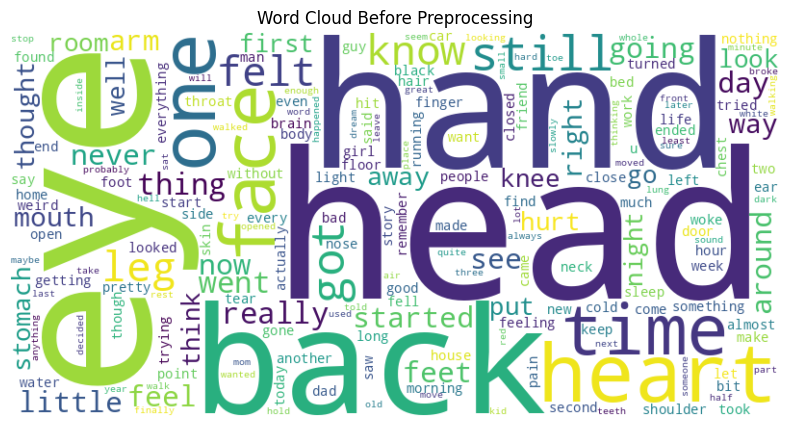

In [37]:
raw_text = ' '.join(df['text'])
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Before Preprocessing')
plt.show()

In [38]:
def clean_text(text):
    """
    Applies a series of cleaning steps to the text.
    1. Converts text to lowercase.
    2. Removes punctuation, numbers, and special characters.
    """
    text = text.lower()
    text = re.sub(r'~~.*?~~', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = contractions.fix(text)
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'http\S+', ' ', text)

    # Remove emojis
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # Remove punctuation but keep letters and numbers for context (like 10/10)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # text = re.sub(r'[^a-z\s]', '', text)
    
    return text

df['clean_text'] = df['text'].apply(clean_text)
print("Original Text:\n", df['text'].iloc[1])
print("\nCleaned Text:\n", df['clean_text'].iloc[1])

Original Text:
 i'm gonna absolutely ~~suck~~ be terrible during my first sexual experience ._.

Cleaned Text:
 i am going to absolutely be terrible during my first sexual experience 


In [39]:
df_t = df_test.copy()
df_t['clean_text'] = df_t['text'].apply(clean_text)
print("Original Text:\n", df_t['text'].iloc[1])
print("\nCleaned Text:\n", df_t['clean_text'].iloc[1])

Original Text:
 anyway, back to tuesday.

Cleaned Text:
 anyway back to tuesday


In [41]:
all_words = ' '.join(df['clean_text']).split()

word_counts = Counter(all_words)

most_common_words = word_counts.most_common(20)
df_most_common = pd.DataFrame(most_common_words, columns=['word', 'count'])
df_most_common.head()

,word,count
0,my,5615
1,i,5207
2,the,4251
3,and,3573
4,to,2936


C:\Users\91762\AppData\Local\Temp\ipykernel_25548\43780543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_most_common, x='count', y='word', palette='rocket')


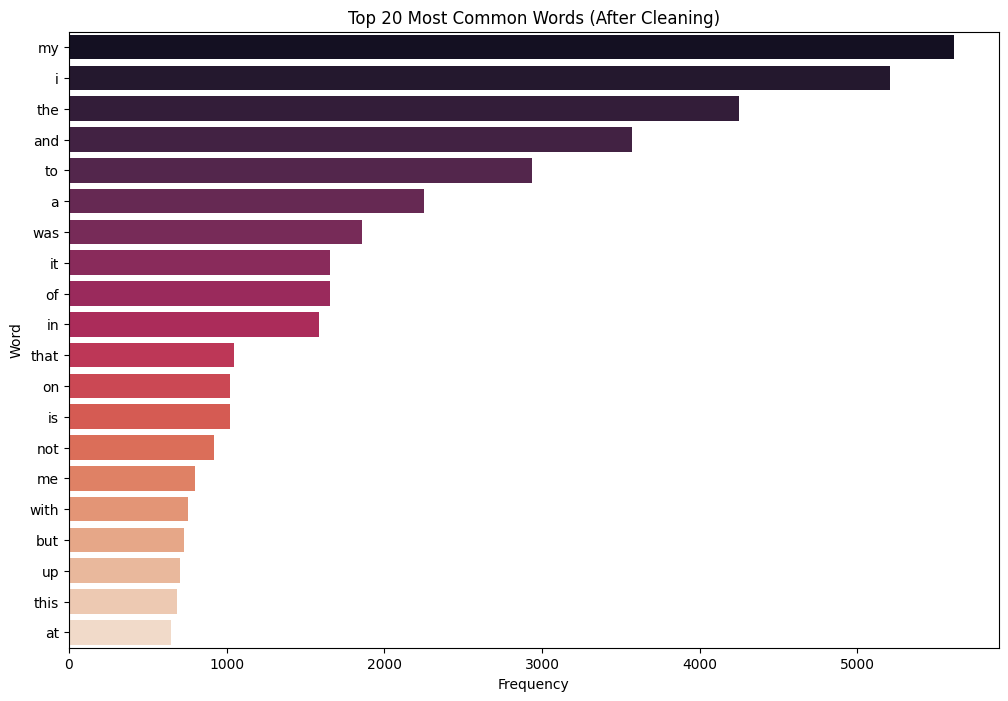

In [42]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df_most_common, x='count', y='word', palette='rocket')
plt.title('Top 20 Most Common Words (After Cleaning)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# MILESTONE 1

In [43]:
original_chars = df['text'].str.len().sum()
cleaned_chars = df['clean_text'].str.len().sum()
reduction_percentage = ((original_chars - cleaned_chars) / original_chars) * 100

print(f"Original total character count: {original_chars}")
print(f"Cleaned total character count: {cleaned_chars}")
print(f"Percentage reduction in characters after cleaning: {reduction_percentage:.2f}%")

Original total character count: 542274
Cleaned total character count: 527967
Percentage reduction in characters after cleaning: 2.64%


In [44]:
stop_words = set(stopwords.words('english'))
all_words = ' '.join(df['clean_text']).split()
unique_words = set(all_words)
common_stopwords = unique_words.intersection(stop_words)
percentage_stopwords = (len(common_stopwords) / len(unique_words)) * 100

print(f"Total number of unique words: {len(unique_words)}")
print(f"Number of unique words that are stop words: {len(common_stopwords)}")
print(f"Percentage of unique words that are stop words: {percentage_stopwords:.2f}%")

Total number of unique words: 8300
Number of unique words that are stop words: 129
Percentage of unique words that are stop words: 1.55%


In [45]:
non_stop_words = [word for word in all_words if word not in stop_words]
word_counts_non_stop = Counter(non_stop_words)

top_5_words = word_counts_non_stop.most_common(5)
fifth_most_common_word = top_5_words[4]
print(f"The top 5 most frequent words (excluding stop words) are: {top_5_words}")
print(f"The 5th most frequent word is: '{fifth_most_common_word[0]}' with a count of {fifth_most_common_word[1]}.")

The top 5 most frequent words (excluding stop words) are: [('head', 539), ('eyes', 438), ('like', 394), ('back', 365), ('heart', 334)]
The 5th most frequent word is: 'heart' with a count of 334.


# Saving datasets (stop words not removed)

In [40]:
df.to_csv("../data/cleaned_train.csv", index=False)
df_t.to_csv("../data/cleaned_test.csv", index=False)